# Stimulus


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
stim_data = pd.read_csv('./EEG/stimulus-times.csv', low_memory=False)
stim_data.rename(columns={'event name': 'event'}, inplace=True)
print(stim_data.shape)
stim_data.head(2)

(131, 2)


,event,time
0,everyone paired,2015-05-09 23:26:34.35+00
1,blinkInstruction,2015-05-09 23:32:36.911+00


In [8]:
print(f"Total number of unique events: {len(set(stim_data['event'].value_counts().keys()))}")

Total number of unique events: 69


### There is an "unlabeled" event as well! So we remove "unlabeled" and "everyone paired" events to match the events (labels) in the EEG-data.csv. Therefore, 67 events for 67 labels.

# Events dictribution


In [18]:
stim_data = stim_data[stim_data['event'] != 'unlabeled']
stim_data = stim_data[stim_data['event'] != 'everyone paired']
print(f"Total number of unique events after removals: {len(set(stim_data['event'].value_counts().keys()))}")

Total number of unique events after removals: 67


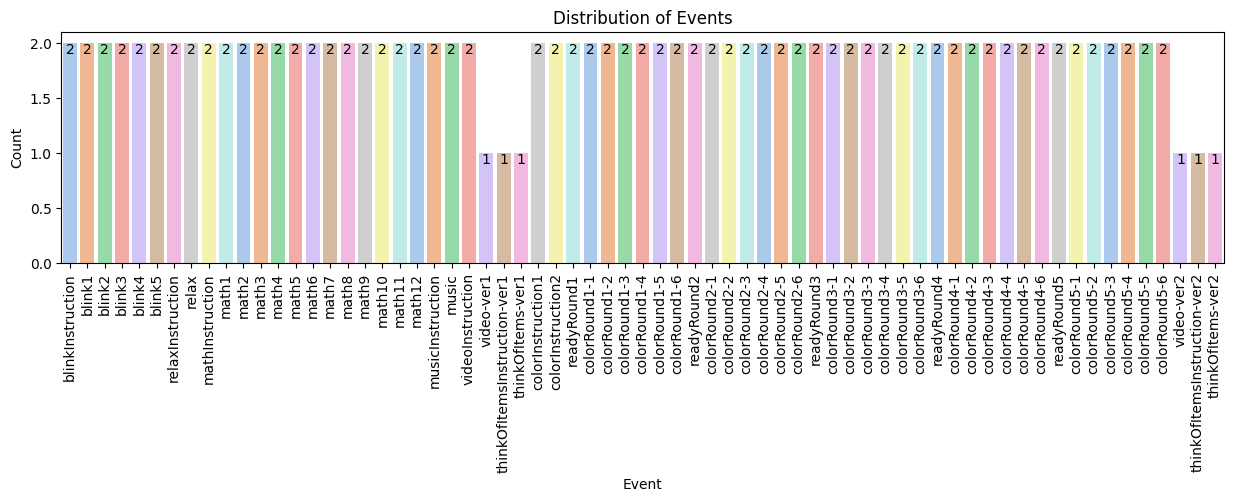

In [19]:
plt.figure(figsize=(15, 3))
sns.countplot(x='event', data=stim_data, palette='pastel', hue='event')
for event in stim_data.event.value_counts().keys():
    count = stim_data[stim_data.event == event].shape[0]
    plt.text(event, count, str(count), ha='center', va='top', rotation=0)
plt.title('Distribution of Events')
plt.xlabel('Event')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.show()